In [1]:
! pip install ydata-profiling

^C



[notice] A new release of pip is available: 25.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import seaborn as sns
df=sns.load_dataset("iris")
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [12]:
from ydata_profiling import ProfileReport
profile=ProfileReport(df,title="EDA",explorative=True)
profile.to_file("output.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|███████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 315.76it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# feature scaling
## Standarization 

In [6]:
import pandas as pd
df=pd.read_csv(r"C:\Users\tyagi\Downloads\Social_Network_Ads.csv")
df.sample(5)

,User ID,Gender,Age,EstimatedSalary,Purchased
331,15589715,Female,48,119000,1
216,15636023,Male,49,65000,0
13,15704987,Male,32,18000,0
74,15592877,Male,32,18000,0
279,15759684,Female,50,36000,1


In [7]:
df=df.iloc[:,2:]

In [8]:
df.sample(5)

,Age,EstimatedSalary,Purchased
239,53,143000,1
369,54,26000,1
341,35,75000,0
377,42,53000,0
64,59,83000,0


In [9]:
df.columns

Index(['Age', 'EstimatedSalary', 'Purchased'], dtype='object')

In [10]:
x=df[['Age', 'EstimatedSalary']]
x.head()

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000


In [11]:
y=df[['Purchased']]
y.head()

,Purchased
0,0
1,0
2,0
3,0
4,0


In [12]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, random_state=42)
x_train.shape ,x_test.shape

((320, 2), (80, 2))

In [13]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()


In [14]:

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [15]:
scaler.mean_

array([3.7871875e+01, 7.0281250e+04])

In [16]:
x_train

,Age,EstimatedSalary
3,27,57000
18,46,28000
202,39,134000
250,44,39000
274,57,26000
...,...,...
71,24,27000
106,26,35000
270,43,133000
348,39,77000


In [26]:
x_train_scaled

array([[-1.06675246, -0.38634438],
       [ 0.79753468, -1.22993871],
       [ 0.11069205,  1.853544  ],
       [ 0.60129393, -0.90995465],
       [ 1.87685881, -1.28811763],
       [-0.57615058,  1.44629156],
       [ 0.3069328 , -0.53179168],
       [ 0.99377543,  0.10817643],
       [-1.16487283,  0.45724994],
       [-1.55735433,  0.31180264],
       [ 1.0918958 ,  0.45724994],
       [-0.18366908, -0.47361276],
       [ 0.20881242, -0.32816546],
       [ 0.3069328 ,  0.28271318],
       [-1.16487283, -1.57901222],
       [ 0.11069205,  0.25362372],
       [ 2.07309956,  1.73718616],
       [ 0.40505317, -0.18271817],
       [ 1.4843773 ,  2.11534913],
       [-0.37990983,  1.21357589],
       [ 1.87685881,  1.50447048],
       [ 0.11069205,  0.02090805],
       [ 0.89565505, -1.31720709],
       [-1.36111358, -1.49174384],
       [-0.18366908, -0.5899706 ],
       [-0.57615058,  2.31897535],
       [ 0.99377543, -1.20084925],
       [-0.77239133,  1.06812859],
       [ 2.17121993,

In [17]:
x_train_scaled=pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled=pd.DataFrame(x_test_scaled,columns=x_test.columns)

In [18]:
x_train_scaled

,Age,EstimatedSalary
0,-1.066752,-0.386344
1,0.797535,-1.229939
2,0.110692,1.853544
3,0.601294,-0.909955
4,1.876859,-1.288118
...,...,...
315,-1.361114,-1.259028
316,-1.164873,-1.026312
317,0.503174,1.824455
318,0.110692,0.195445


In [19]:
x_train_scaled

,Age,EstimatedSalary
0,-1.066752,-0.386344
1,0.797535,-1.229939
2,0.110692,1.853544
3,0.601294,-0.909955
4,1.876859,-1.288118
...,...,...
315,-1.361114,-1.259028
316,-1.164873,-1.026312
317,0.503174,1.824455
318,0.110692,0.195445


In [20]:
import numpy as np
np.round(x_train.describe(),1)

,Age,EstimatedSalary
count,320.0,320.0
mean,37.9,70281.2
std,10.2,34430.6
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,71000.0
75%,45.0,88000.0
max,60.0,150000.0


In [21]:
np.round(x_train_scaled.describe(),1)

,Age,EstimatedSalary
count,320.0,320.0
mean,-0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.7,0.5
max,2.2,2.3


Text(0.5, 1.0, 'After Scaling')

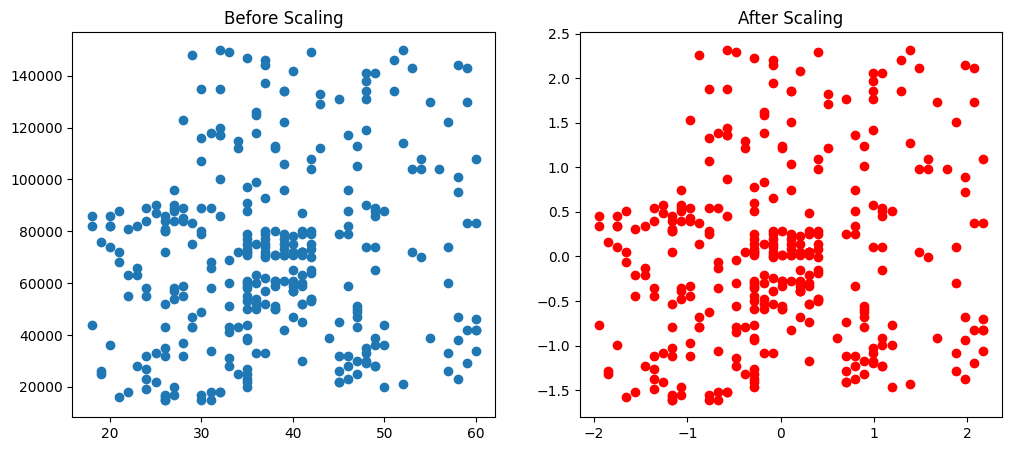

In [22]:
import matplotlib.pyplot as plt
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))
ax1.scatter(x_train['Age'],x_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(x_train_scaled['Age'],x_train_scaled['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")

<Axes: title={'center': 'after scaling'}, xlabel='Age', ylabel='Density'>

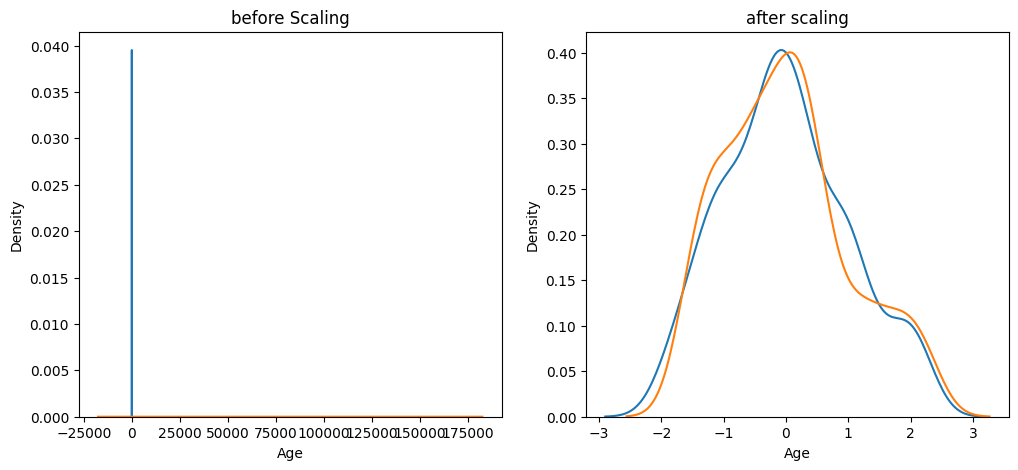

In [23]:
import seaborn as sns
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))
ax1.set_title("before Scaling")
sns.kdeplot(x_train['Age'],ax=ax1)
sns.kdeplot(x_train['EstimatedSalary'],ax=ax1)
ax2.set_title("after scaling")
sns.kdeplot(x_train_scaled['Age'],ax=ax2)
sns.kdeplot(x_train_scaled['EstimatedSalary'],ax=ax2)

In [25]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr_scaled=LogisticRegression()
lr.fit(x_train,y_train)
lr_scaled.fit(x_train_scaled,y_train)

C:\Users\tyagi\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\tyagi\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [26]:
normal_pred=lr.predict(x_test)
scaled_pred=lr_scaled.predict(x_test_scaled)


In [27]:
from sklearn.metrics import accuracy_score
print("actual",accuracy_score(y_test,normal_pred))
print("scaled",accuracy_score(y_test,scaled_pred))

actual 0.8875
scaled 0.8625


In [29]:
from sklearn.tree import DecisionTreeClassifier
dr=DecisionTreeClassifier()
dr_scaled=DecisionTreeClassifier()


In [30]:
dr.fit(x_train,y_train)
dr_scaled.fit(x_train_scaled,y_train)


DecisionTreeClassifier()

In [31]:
y_pred=dr.predict(x_test)
y_scaled_pre=dr_scaled.predict(x_test_scaled)


In [33]:
print("normal",accuracy_score(y_test,y_pred))
print("scaled:",accuracy_score(y_test,y_scaled_pre))

normal 0.8375
scaled: 0.8375


# effect of outlier


In [34]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [37]:
new_data=pd.DataFrame({
    'Age':[5,90,95],
    'EstimatedSalary':[1000,250000,350000],
    'Purchased':[0,1,1]
})

In [38]:
df=pd.concat([df,new_data],ignore_index=True)

In [39]:
df.tail(5)

,Age,EstimatedSalary,Purchased
398,36,33000,0
399,49,36000,1
400,5,1000,0
401,90,250000,1
402,95,350000,1


<Axes: xlabel='Age', ylabel='EstimatedSalary'>

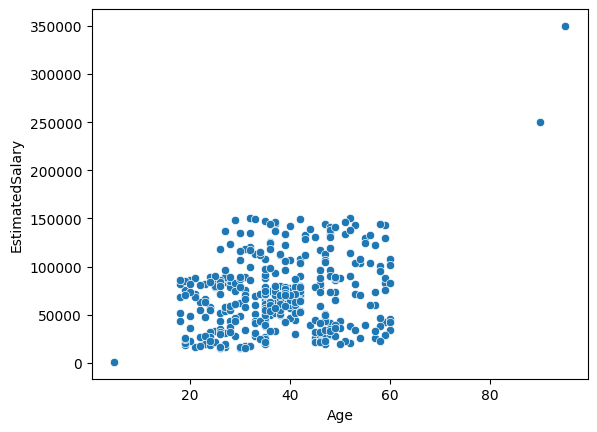

In [42]:
sns.scatterplot(x=df['Age'],y=df['EstimatedSalary'])

In [43]:
x1=df[['Age','EstimatedSalary']]
y1=df[['Purchased']]

In [46]:
x1_train,x1_test,y1_train,y1_test=train_test_split(x1,y1,test_size=0.2,random_state=42)
x1_train.shape , x1_test.shape

((322, 2), (81, 2))

In [48]:
scaler=StandardScaler()

In [49]:
x1_train_scaled=scaler.fit_transform(x1_train)
x1_test_scaled=scaler.transform(x1_test)

In [53]:
x1_train_scaled = pd.DataFrame(x1_train_scaled, columns=x1_train.columns)
x1_test_scaled = pd.DataFrame(x1_test_scaled, columns=x1_test.columns)

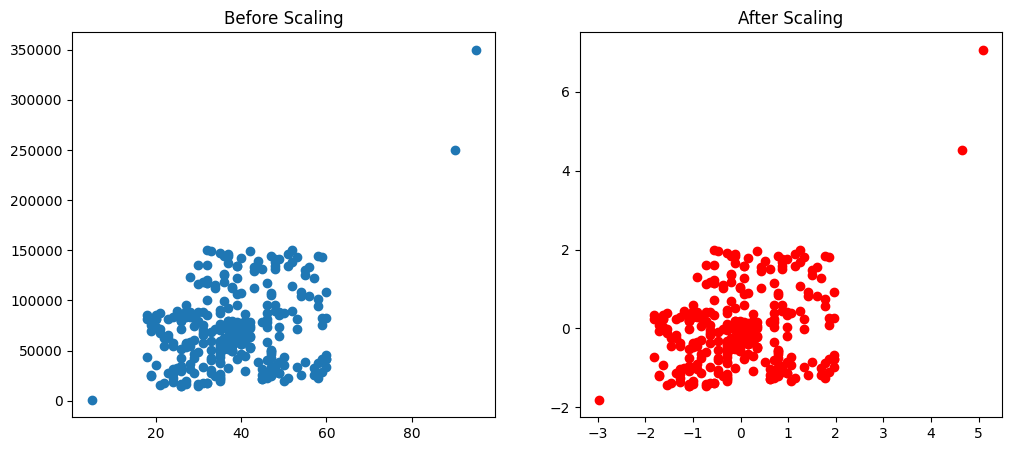

In [54]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(x1_train['Age'], x1_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(x1_train_scaled['Age'], x1_train_scaled['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")
plt.show()